# 04 -- UpSet vs Venn vs Network: Choosing the Right Visualization

Venn diagrams, UpSet plots, and Network graphs each reveal different facets
of overlapping sets. Picking the wrong one wastes space and confuses readers.
This notebook shows each visualization applied to 3-set, 5-set, and 7-set
data so you can see exactly when each approach shines -- and when it struggles.

**What you will learn:**

- Why Venn diagrams work beautifully for 2-4 sets but deteriorate beyond that
- Why UpSet plots are the recommended alternative for 5+ sets
- When a Network plot adds value regardless of set count


In [1]:
import venn_diagram_lab as vdl

print(f'venn-diagram-lab {vdl.__version__}')

venn-diagram-lab 0.6.0


## Rule-of-thumb: which plot to pick

| Set count | Venn diagram | UpSet plot | Network plot |
|-----------|-------------|------------|--------------|
| 2-4 sets  | Best choice -- regions are readable | Works, but overkill | Use when pairwise relationships are the focus |
| 5-7 sets  | Gets crowded, hard to read | **Preferred** -- exact bars, scalable | Useful for spotting clusters and strong edges |
| 8-9 sets  | Avoid -- nearly unreadable | **Recommended** -- threshold filter helps | Helpful, especially with Jaccard/FE edge weights |

A good default rule:

> Use **Venn** for <=4 sets, **UpSet** for >=5 sets, and **Network** whenever
> pairwise overlap strength matters more than the full intersection breakdown.


## 3 sets -- Venn is the natural choice

With three sets there are exactly 7 non-empty intersection regions. A Venn diagram
maps them perfectly: each region is visible, labeled, and easy to trace back to
its contributing sets.


In [2]:
# Compact 3-set cancer gene example
ds_3 = vdl.Dataset.from_dict({
    'TP53_Pathway': {'CDKN1A', 'MDM2', 'BAX', 'BBC3', 'PUMA'},
    'Apoptosis':    {'BAX', 'BBC3', 'CASP3', 'CASP9', 'BCL2'},
    'DNA_Repair':   {'CDKN1A', 'BRCA1', 'BRCA2', 'ATM', 'CASP3'},
})
r_3 = vdl.analyze(ds_3, model='auto')
print('Model selected:', r_3.model)
print('Non-empty regions:', len(r_3.regions))

Model selected: venn-3-set
Non-empty regions: 6


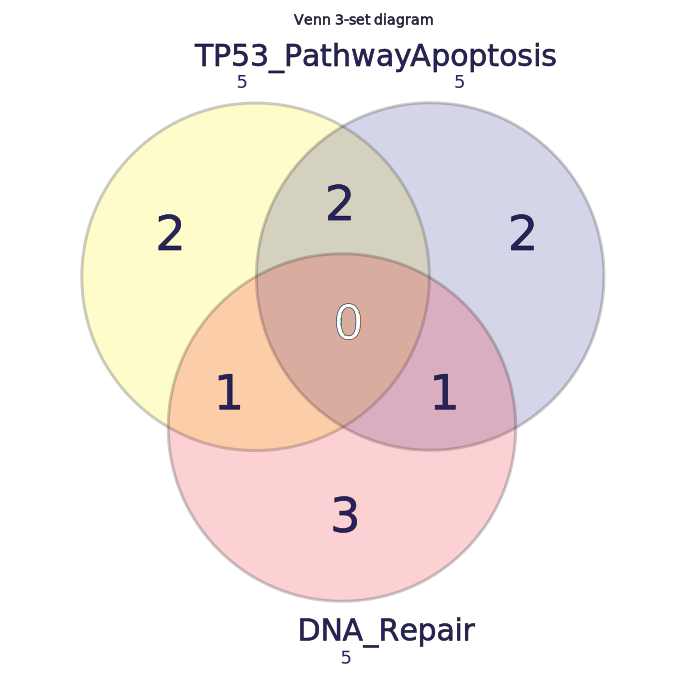

In [3]:
# Venn diagram -- clean and easy to read for 3 sets
r_3.render_venn()

## 5 sets -- Venn becomes crowded

We load a real dataset of MSigDB cancer pathway gene sets (5 sets, all from
Molecular Signatures Database hallmark pathways). The Venn diagram can still
render 31 regions, but many regions overlap visually and the labels compete
for space. Notice how the diagram feels cluttered compared to the 3-set version.


In [4]:
# Real MSigDB cancer pathways dataset (5 sets)
ds_5 = vdl.load_sample('dataset_real_msigdb_cancer_pathways')
r_5 = vdl.analyze(ds_5, model='auto')
print('Set names:', ds_5.set_names)
print('Model selected:', r_5.model)
print('Non-empty regions:', len(r_5.regions))

Set names: ['P53_PATHWAY', 'APOPTOSIS', 'G2M_CHECKPOINT', 'E2F_TARGETS', 'DNA_REPAIR']
Model selected: venn-5-set-grunbaum
Non-empty regions: 19


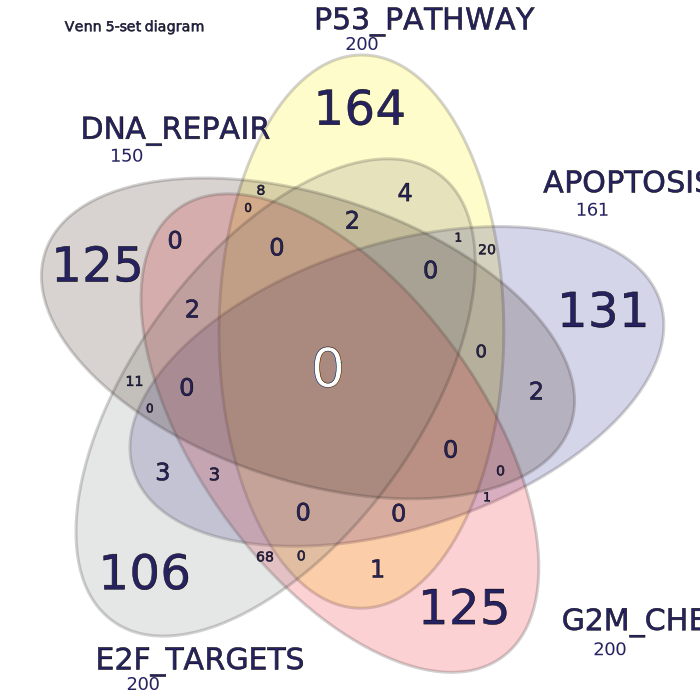

In [5]:
# Venn diagram for 5 sets -- readable but getting busy
r_5.render_venn()

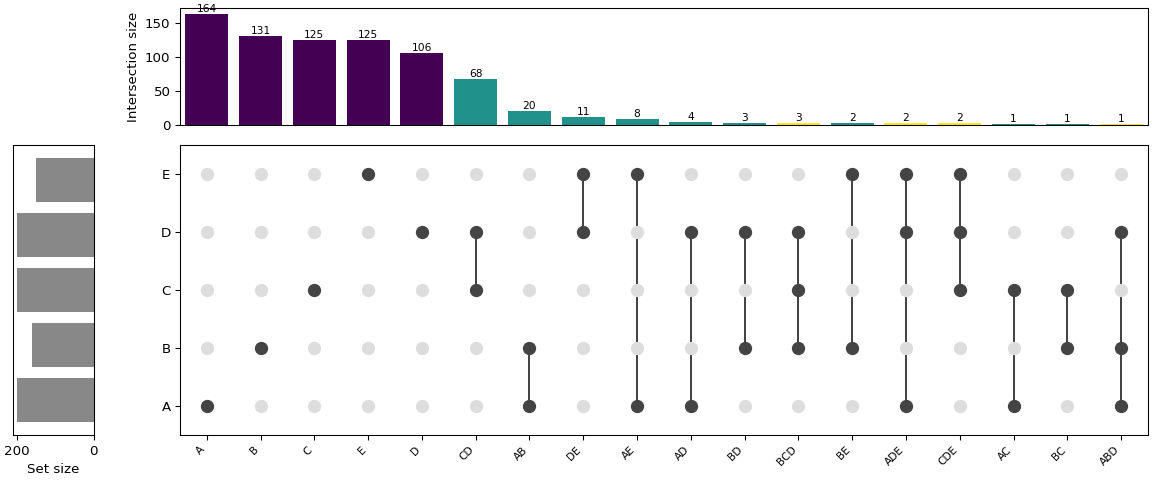

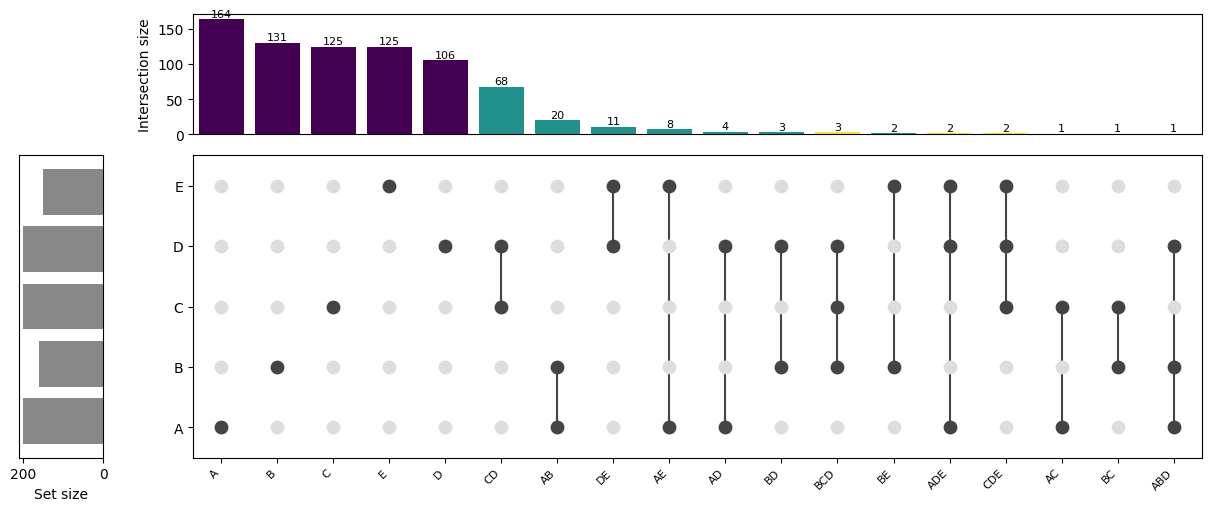

In [6]:
# UpSet plot for 5 sets -- recommended alternative
# Each bar represents one intersection; the dot matrix shows which sets contribute.
r_5.render_upset()

## 7 sets -- UpSet is essential

A 7-set Venn diagram has 127 possible non-empty regions. Even the best template
cannot make that legible. UpSet collapses the visual complexity to a ranked
bar chart: the tallest bars are the biggest intersections, and you can filter
to show only the most populated ones.

We generate a synthetic 7-set dataset where each set has 20 unique items plus
one item (`'shared'`) present in all sets.


In [7]:
# Synthetic 7-set dataset: 20 unique items per set + 1 shared item
ds_7 = vdl.Dataset.from_dict(
    {chr(ord('A') + i): {f'item{j}{i}' for j in range(20)} | {'shared'}
     for i in range(7)}
)
r_7 = vdl.analyze(ds_7, model='auto')
print('Model selected:', r_7.model)
print('Total possible regions:', len(r_7.regions))

Model selected: venn-7-set-grunbaum
Total possible regions: 127


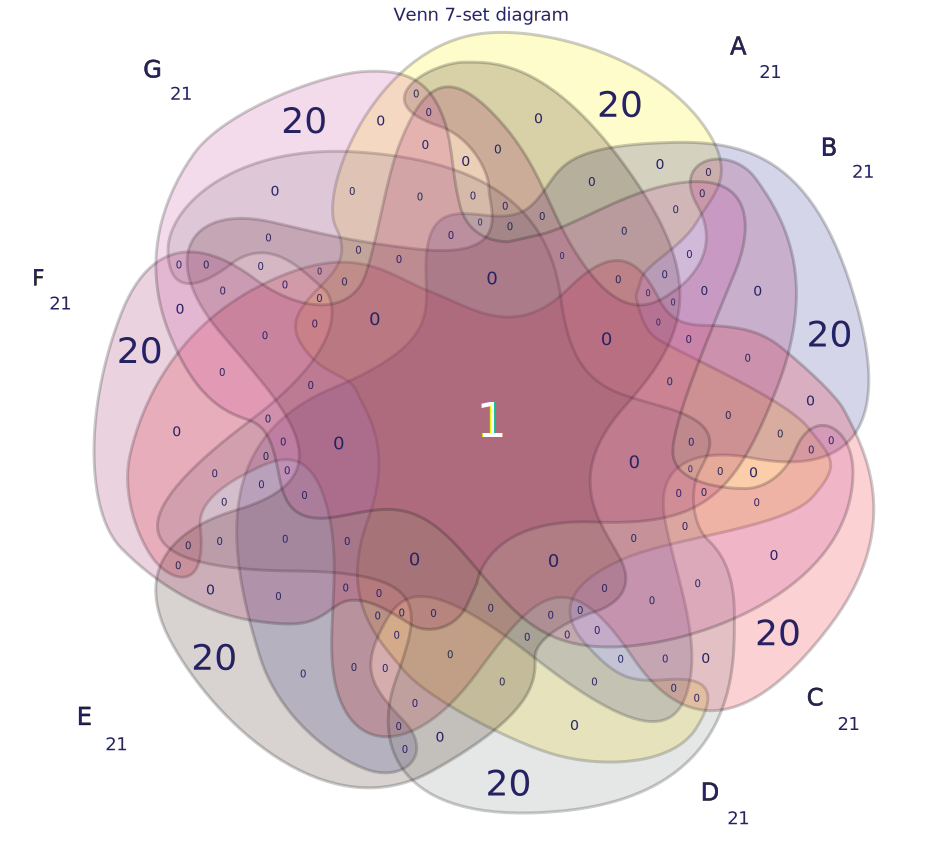

In [8]:
# Venn diagram for 7 sets -- note how overwhelming this becomes
r_7.render_venn()

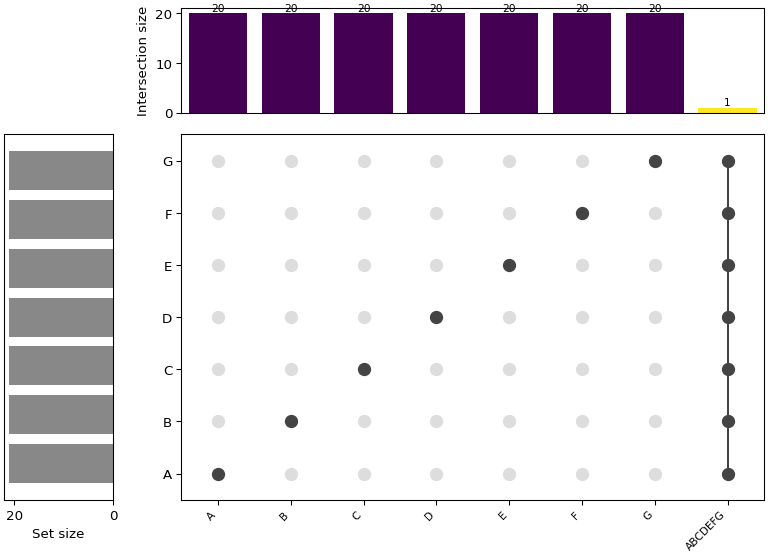

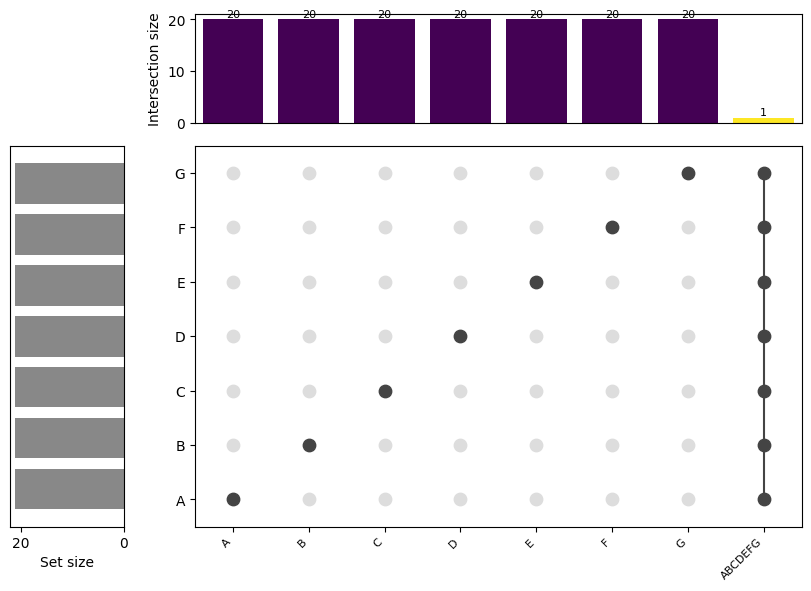

In [9]:
# UpSet plot for 7 sets -- all intersections ranked by size
r_7.render_upset()

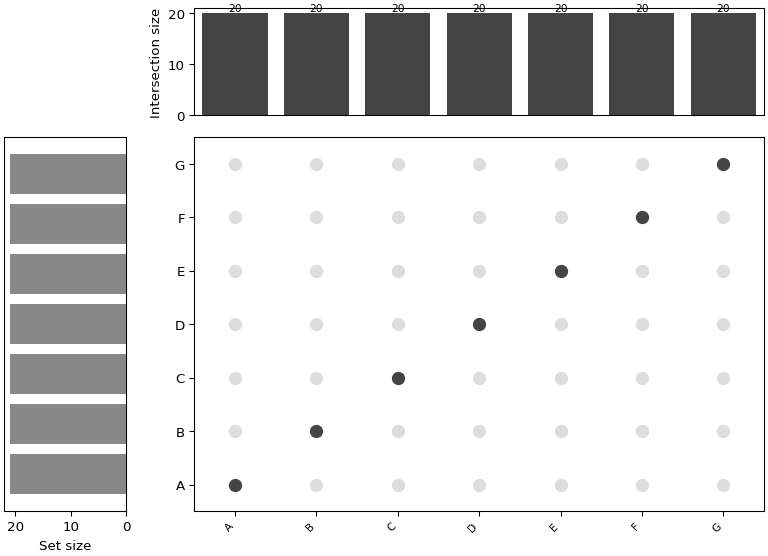

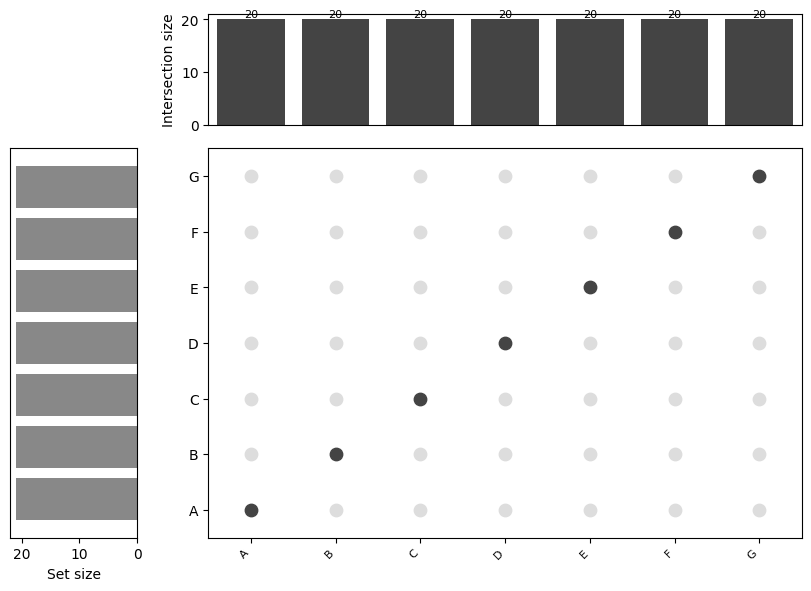

In [10]:
# Threshold filter: show only intersections with >= 2 items
# This removes noise and highlights meaningful overlaps.
r_7.render_upset(threshold=2)

## Network plot -- relationship-focused view

The Network plot represents sets as nodes and pairwise overlaps as edges.
Edge weight and color reflect overlap strength (Jaccard similarity by default).
It answers a different question: *which sets are most similar to each other?*

The 5-set cancer dataset works well here because the pathway groupings
create a meaningful cluster structure.


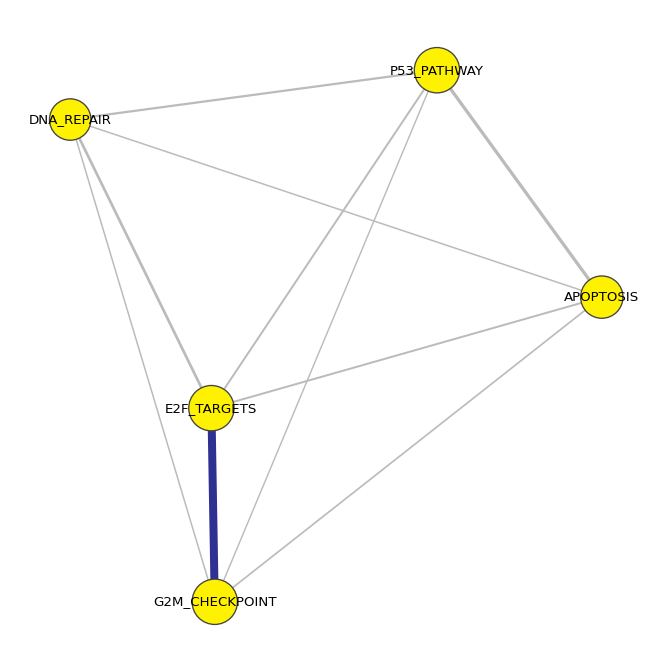

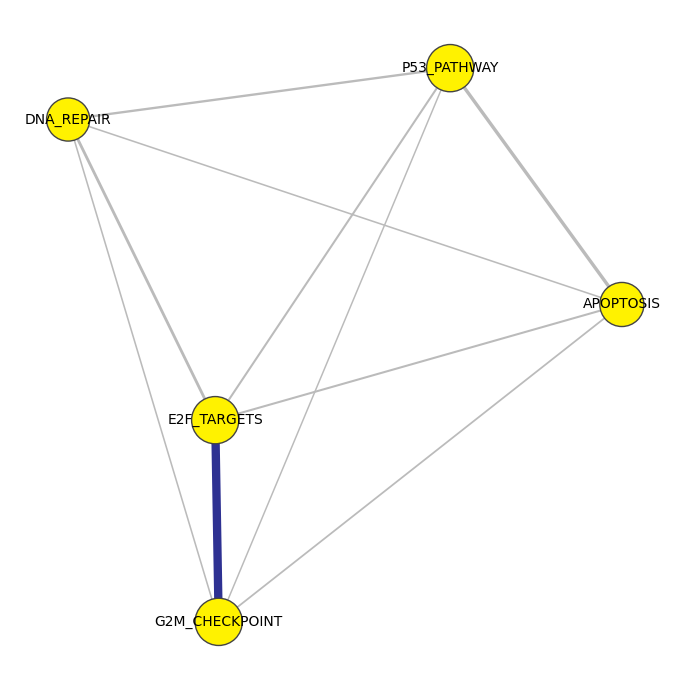

In [11]:
# Network plot for the 5-set cancer dataset
# Node size = set cardinality, edge weight = pairwise Jaccard similarity.
r_5.render_network()

## Next steps

- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- Jaccard, Dice, and hypergeometric enrichment explained with real data
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- generate a publication-ready multi-page PDF report combining Venn, UpSet, Network, and statistics
